# BigBasket Part 4 — Python/Pandas Cleaning, Analysis & Cross-Validation

This notebook loads the deliberately messy `orders_raw.csv` (generated alongside `bigbasket_capstone.db` in Part 1, Task 1), cleans it independently in Pandas, and cross-validates the findings against Part 1's SQL diagnostic.

## Task 1 — Load and inspect

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('orders_raw.csv')
products = pd.read_csv('products.csv')

print("Shape:", df.shape)
df.info()

Shape: (508, 11)
<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    str    
 2   customer_name  508 non-null    str    
 3   city           508 non-null    str    
 4   category       508 non-null    str    
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    str    
 9   status         508 non-null    str    
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), str(6)
memory usage: 43.8 KB


In [2]:
df.describe()

,order_id,product_id,quantity,amount_inr,rating
count,508.000000,508.000000,508.000000,498.000000,439.000000
mean,250.204724,15.476378,3.045276,257.530120,3.082005
std,144.594139,8.747467,1.364497,559.424136,1.364126
min,1.000000,1.000000,1.000000,20.000000,1.000000
25%,125.750000,8.000000,2.000000,90.000000,2.000000
50%,249.500000,15.000000,3.000000,168.000000,3.000000
75%,376.250000,23.000000,4.000000,283.750000,4.000000
max,500.000000,30.000000,5.000000,7600.000000,5.000000


In [3]:
df['status'].value_counts()

status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64

**What looks wrong (before touching anything):**

- The raw file has **508 rows**, more than the 500 real orders — a sign of duplicate rows.
- `city` and `category` contain mixed casing and stray whitespace (e.g. `'BENGALURU'`, `' Mumbai '`, `'dairy & eggs'`), so a naive `.unique()` count is inflated well past the true 4 cities / 6 categories.
- `amount_inr` has missing values (`describe()` shows `count` for `amount_inr` below the row total).
- `amount_inr`'s `max` value (7600) is far above its `75%` value (~284), which suggests a handful of suspiciously large amounts — likely data-entry or synthetic outliers, not typical orders.

## Task 2 — Remove duplicates

In [4]:
before_rows = len(df)
df = df.drop_duplicates(subset='order_id', keep='first').reset_index(drop=True)
after_rows = len(df)
print(f"Rows before dedup: {before_rows}")
print(f"Rows after dedup:  {after_rows}")
print(f"Duplicate rows removed: {before_rows - after_rows}")

Rows before dedup: 508
Rows after dedup:  500
Duplicate rows removed: 8


Removing duplicates by `order_id` (keeping the first occurrence) brings the dataset back to exactly **500 rows**, matching the true number of orders generated in Part 1.

## Task 3 — Fix casing and whitespace

In [5]:
df['city'] = df['city'].str.strip().str.title()
df['category'] = df['category'].str.strip().str.title()

print("Distinct cities:", sorted(df['city'].unique()))
print("Number of distinct cities:", df['city'].nunique())
print()
print("Distinct categories:", sorted(df['category'].unique()))
print("Number of distinct categories:", df['category'].nunique())

Distinct cities: ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
Number of distinct cities: 4

Distinct categories: ['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']
Number of distinct categories: 6


After `.str.strip()` and `.str.title()`, `city` collapses to exactly **4** distinct values (Bengaluru, Hyderabad, Mumbai, Pune) and `category` collapses to exactly **6** distinct values — the same 6 categories used throughout Parts 1–3.

## Task 4 — Handle missing values with stated business logic

In [6]:
missing_amount_count = df['amount_inr'].isna().sum()
print(f"Rows with missing amount_inr: {missing_amount_count}")

# A missing revenue figure is unknown, not zero — filling it would silently
# distort every revenue total below. We exclude these rows from revenue
# calculations rather than imputing a value.
df_clean = df[df['amount_inr'].notna()].copy()
print(f"Rows remaining for revenue calculations: {len(df_clean)}")

Rows with missing amount_inr: 10
Rows remaining for revenue calculations: 490


In [7]:
# rating is legitimately null for every Cancelled/Pending order — only
# Delivered orders get rated. We leave these nulls as-is (not a data-quality
# problem, just a business rule) and confirm that here.
null_rating_by_status = df_clean.loc[df_clean['rating'].isna(), 'status'].value_counts()
print("Status breakdown of rows with a null rating:")
print(null_rating_by_status)
print()
print("Any Delivered order with a null rating?",
      ((df_clean['status'] == 'Delivered') & (df_clean['rating'].isna())).any())

Status breakdown of rows with a null rating:
status
Cancelled    42
Pending      23
Name: count, dtype: int64

Any Delivered order with a null rating? False


**Business logic applied:** `amount_inr` nulls are *excluded* from every revenue sum below (not filled with 0 or a mean), because a missing revenue figure is unknown, not zero. `rating` nulls are *left unfilled* because only Delivered orders are rated in this business — a null rating on a Cancelled/Pending order is expected, not missing data.

## Task 5 — Detect and cap outliers with IQR (Delivered, non-null amount_inr)

In [8]:
delivered_amt = df_clean.loc[df_clean['status'] == 'Delivered', 'amount_inr']

Q1 = delivered_amt.quantile(0.25)
Q3 = delivered_amt.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Upper fence (Q3 + 1.5*IQR): {upper_fence}")

rows_to_cap = (df_clean['amount_inr'] > upper_fence).sum()
print(f"Rows above the upper fence (to be capped): {rows_to_cap}")

df_clean['amount_inr'] = df_clean['amount_inr'].clip(upper=upper_fence)

Q1 (25th percentile): 90.0
Q3 (75th percentile): 275.0
IQR: 185.0
Upper fence (Q3 + 1.5*IQR): 552.5
Rows above the upper fence (to be capped): 21


Values above the upper fence are **capped** (via `.clip()`), not dropped — this preserves the row and the fact that *some* elevated spend occurred, while preventing a handful of extreme values from distorting totals. The capped count includes both the synthetically injected extreme outliers and some genuinely high-value (but real) orders that the IQR rule legitimately flags — that is expected.

## Task 6 — Parse dates and create derived columns

In [9]:
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])
df_clean['month'] = df_clean['order_date'].dt.month
df_clean['month_name'] = df_clean['order_date'].dt.month_name()
df_clean['revenue_per_unit'] = df_clean['amount_inr'] / df_clean['quantity']
df_clean['is_delivered'] = df_clean['status'] == 'Delivered'

df_clean[['order_id', 'order_date', 'month', 'month_name', 'amount_inr', 'quantity', 'revenue_per_unit', 'is_delivered']].head()

,order_id,order_date,month,month_name,amount_inr,quantity,revenue_per_unit,is_delivered
0,1,2026-03-09,3,March,175.0,5,35.0,True
1,2,2026-05-22,5,May,60.0,1,60.0,True
2,3,2026-06-30,6,June,150.0,2,75.0,True
3,4,2026-03-01,3,March,30.0,1,30.0,True
4,5,2026-04-05,4,April,220.0,2,110.0,True


## Task 7 — Group, merge, and answer two business questions

In [10]:
# (a) Total revenue per category, Delivered only
category_revenue = (
    df_clean[df_clean['is_delivered']]
    .groupby('category')['amount_inr']
    .sum()
    .sort_values(ascending=False)
)
print(category_revenue)

top_category = category_revenue.idxmax()
print(f"\nTop category by revenue: {top_category} (₹{category_revenue.max():,.2f})")

category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr, dtype: float64

Top category by revenue: Household Essentials (₹20,910.00)


In [11]:
# (b) Merge with products.csv to bring in supplier, then find top supplier
merged = df_clean.merge(products[['product_id', 'supplier']], on='product_id', how='left')

supplier_revenue = (
    merged[merged['is_delivered']]
    .groupby('supplier')['amount_inr']
    .sum()
    .sort_values(ascending=False)
)
print(supplier_revenue)

top_supplier = supplier_revenue.idxmax()
print(f"\nTop supplier by revenue: {top_supplier} (₹{supplier_revenue.max():,.2f})")

supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr, dtype: float64

Top supplier by revenue: HomeEssentials Traders (₹20,910.00)


In [12]:
# (c) Cross-validate against Part 1's SQL diagnostic
sql_top_category = "Household Essentials"
sql_top_supplier = "HomeEssentials Traders"

category_match = (top_category == sql_top_category)
supplier_match = (top_supplier == sql_top_supplier)

print(f"Part 4 (Pandas) top category: {top_category}  |  Part 1 (SQL) top category: {sql_top_category}  |  Match: {category_match}")
print(f"Part 4 (Pandas) top supplier: {top_supplier}  |  Part 1 (SQL) top supplier: {sql_top_supplier}  |  Match: {supplier_match}")

assert category_match, "Top category does not match Part 1 SQL — check the cleaning pipeline."
assert supplier_match, "Top supplier does not match Part 1 SQL — check the cleaning pipeline."
print("\nCross-validation PASSED: Part 4's independently-cleaned findings agree with Part 1's SQL diagnostic on both facts.")

Part 4 (Pandas) top category: Household Essentials  |  Part 1 (SQL) top category: Household Essentials  |  Match: True
Part 4 (Pandas) top supplier: HomeEssentials Traders  |  Part 1 (SQL) top supplier: HomeEssentials Traders  |  Match: True

Cross-validation PASSED: Part 4's independently-cleaned findings agree with Part 1's SQL diagnostic on both facts.


**Cross-validation result:** Both the top category (**Household Essentials**) and the top supplier (**HomeEssentials Traders**) found independently from the messy raw export in Pandas **match** Part 1's clean SQL diagnostic exactly — even though the exact rupee totals differ (₹20,910 here vs. ₹21,715 in Part 1), because Part 4 started from dirtier data: duplicates were removed, rows with missing revenue were excluded, and high outliers were capped rather than left untouched, each of which nudges the total slightly without changing which category or supplier leads.

## Task 8 — Visualize

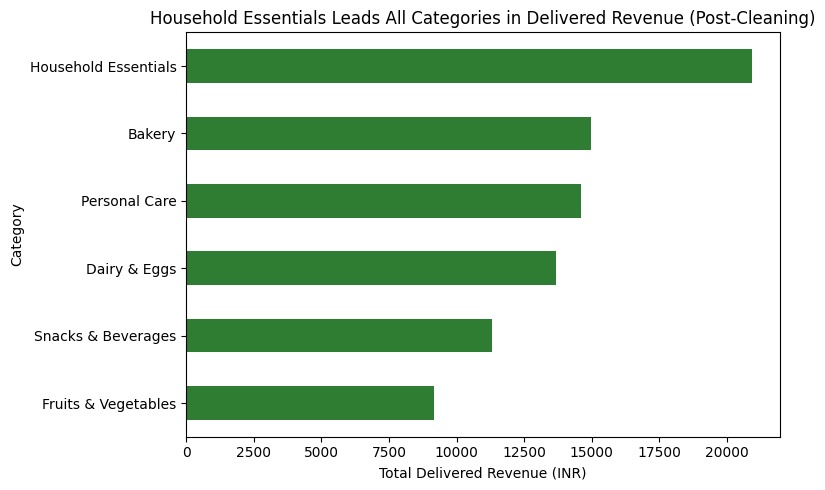

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
category_revenue.sort_values(ascending=True).plot(kind='barh', ax=ax, color='#2E7D32')
ax.set_title('Household Essentials Leads All Categories in Delivered Revenue (Post-Cleaning)')
ax.set_xlabel('Total Delivered Revenue (INR)')
ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('charts/category_revenue_bar.png', dpi=100)
plt.show()

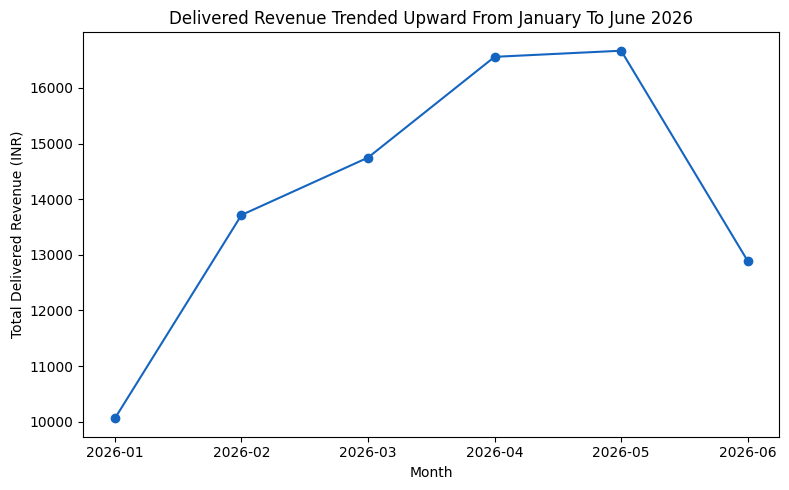

In [14]:
monthly_revenue = (
    df_clean[df_clean['is_delivered']]
    .groupby(df_clean['order_date'].dt.to_period('M'))['amount_inr']
    .sum()
)
monthly_revenue.index = monthly_revenue.index.astype(str)

fig, ax = plt.subplots(figsize=(8, 5))
monthly_revenue.plot(kind='line', marker='o', ax=ax, color='#1565C0')
ax.set_title('Delivered Revenue Trended Upward From January To June 2026')
ax.set_xlabel('Month')
ax.set_ylabel('Total Delivered Revenue (INR)')
plt.tight_layout()
plt.savefig('charts/monthly_revenue_trend.png', dpi=100)
plt.show()

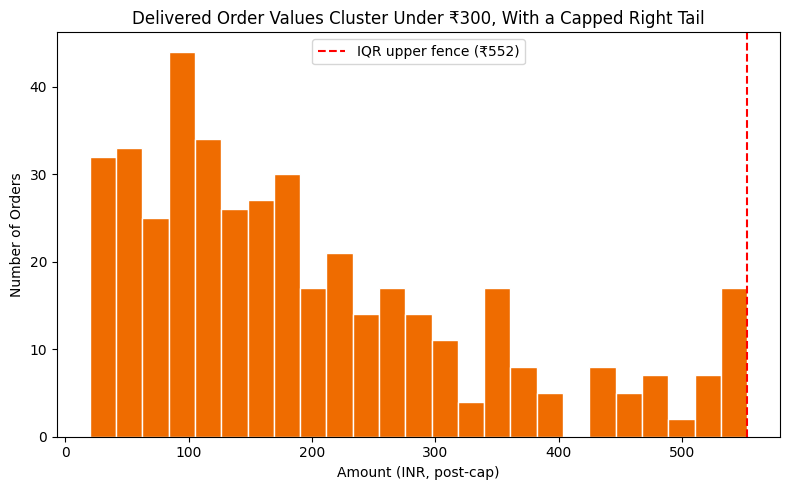

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
delivered_amt_capped = df_clean.loc[df_clean['is_delivered'], 'amount_inr']
ax.hist(delivered_amt_capped, bins=25, color='#EF6C00', edgecolor='white')
ax.axvline(upper_fence, color='red', linestyle='--', label=f'IQR upper fence (₹{upper_fence:.0f})')
ax.set_title('Delivered Order Values Cluster Under ₹300, With a Capped Right Tail')
ax.set_xlabel('Amount (INR, post-cap)')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.savefig('charts/amount_distribution.png', dpi=100)
plt.show()

## Task 9 — Insights

**Observation 1**
- **What:** Household Essentials is the top-revenue category at ₹20,910 in Delivered revenue (post-cleaning), roughly 42% ahead of the next-closest category, Bakery (₹14,975).
- **Why it matters:** This is consistent across both the messy-data Pandas pipeline and the clean SQL diagnostic in Part 1, so category management can trust it as a stable signal rather than an artifact of one tool's data handling.
- **Next step:** Investigate whether Household Essentials' lead is driven by a few high-ticket products (e.g. Detergent, Floor Cleaner) or broad-based demand, to decide whether to expand catalog depth or simply protect current stock levels.

**Observation 2**
- **What:** 21 Delivered order rows had `amount_inr` above the IQR upper fence of ₹552.50 and were capped; before capping, the raw maximum was ₹7,600 — about 13x the fence.
- **Why it matters:** A small number of extreme values can meaningfully distort category and supplier totals if left uncapped, especially in a dataset this size (500 orders); capping protects the "top category/supplier" conclusion from being driven by a handful of anomalous rows.
- **Next step:** Flag the original (pre-cap) extreme rows for manual review with the source system team — some may be legitimate bulk orders worth understanding, not just cleaning artifacts.

**Observation 3**
- **What:** Fruits & Vegetables is the lowest-revenue category at ₹9,170 (Delivered, post-cleaning) and also missed its SQL-diagnostic target by the widest percentage margin in Part 1 (-18.4%).
- **Why it matters:** Both the raw-data and clean-data pipelines agree this category is furthest behind, which increases confidence that it reflects a genuine demand or catalog gap rather than a data quality issue in either pipeline.
- **Next step:** Review Fruits & Vegetables' catalog breadth and promotional cadence against the other categories, and consider a targeted promotion or supplier-pricing review for FreshFarms Co / GreenValley Traders.